In [61]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Input

In [38]:
df = pd.read_csv('Churn_Modelling.csv')

In [39]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [40]:
try:
    df.drop(columns=['RowNumber','CustomerId','Surname'],inplace=True)
except:
    pass

In [41]:
df['Age_group'] = pd.qcut(df['Age'], q=4, labels=['Q1','Q2','Q3','Q4'])

In [42]:
df = pd.get_dummies(data=df,columns=['Geography','Gender','Age_group'],drop_first=True,dtype='int64')

In [43]:
df[df.describe().columns].corr()['Exited'].sort_values(ascending = False)

Exited               1.000000
Age_group_Q4         0.332728
Age                  0.285323
Geography_Germany    0.173488
Balance              0.118533
EstimatedSalary      0.012097
Age_group_Q3         0.003908
HasCrCard           -0.007138
Tenure              -0.014001
CreditScore         -0.027094
NumOfProducts       -0.047820
Geography_Spain     -0.052667
Gender_Male         -0.106512
Age_group_Q2        -0.129211
IsActiveMember      -0.156128
Name: Exited, dtype: float64

In [44]:
X,y = df.drop(columns=['Exited']), df['Exited']

In [46]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.2,random_state=42,stratify=y)

In [48]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [110]:
model = Sequential()
model.add(Input(shape=(14,)))
model.add(Dense(14,activation='relu'))
model.add(Dense(14,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [92]:
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 14)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 14)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 14)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 645 (2.52 KB)

 Trainable params: 645 (2.52 KB)

 Non-trainable params: 0 (0.00 B)

In [111]:
model.compile(loss='binary_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [112]:
history = model.fit(X_train_scaled,y_train,epochs=100,validation_split=.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7987 - loss: 0.4821 - val_accuracy: 0.8194 - val_loss: 0.4376
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8164 - loss: 0.4344 - val_accuracy: 0.8306 - val_loss: 0.4186
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8191 - loss: 0.4209 - val_accuracy: 0.8381 - val_loss: 0.4081
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8281 - loss: 0.4131 - val_accuracy: 0.8456 - val_loss: 0.4050
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8305 - loss: 0.4082 - val_accuracy: 0.8469 - val_loss: 0.3979
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8305 - loss: 0.4050 - val_accuracy: 0.8506 - val_loss: 0.3959
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8314 - loss: 0.4020 - val_accuracy: 0.8462 - val_loss: 0.3925
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8316 - loss: 0.4000 - val_accu

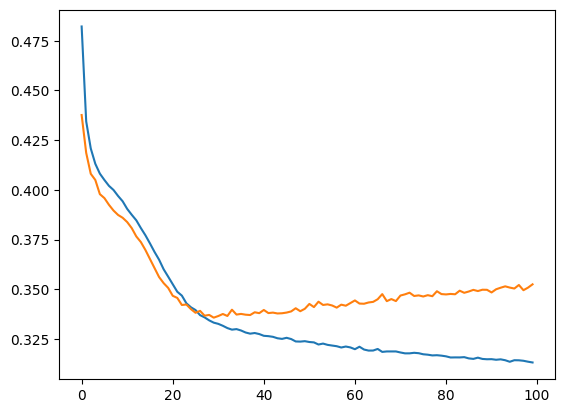

In [113]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.show()

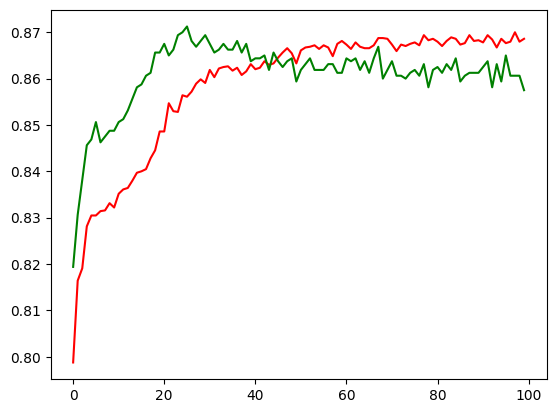

In [114]:
plt.plot(history.history['accuracy'],color='r')
plt.plot(history.history['val_accuracy'],color='g')
plt.show()

In [115]:
model.layers[0].get_weights()

[array([[ 1.56670853e-01, -9.69392657e-02, -6.87248483e-02,
         -1.56879723e-01, -3.70841771e-01, -4.85663675e-02,
         -3.76172774e-02,  7.79430792e-02, -4.11058255e-02,
         -2.04362631e-01, -3.98941427e-01, -6.40720278e-02,
          4.97810617e-02, -1.02605760e-01],
        [ 1.21750355e+00,  2.28483453e-01, -2.35449001e-01,
         -3.64632636e-01, -1.37007877e-01,  3.92639935e-01,
         -7.88191259e-01, -3.16207558e-01,  5.01419067e-01,
         -5.74939549e-01,  8.67309213e-01, -1.98531285e-01,
          3.96205992e-01, -5.18525243e-01],
        [ 4.57221478e-01,  1.34212896e-01, -2.21456178e-02,
          1.27444431e-01, -7.29960715e-03,  1.06571756e-01,
         -1.28747486e-02, -2.77764071e-03, -6.61440864e-02,
         -5.32427430e-02, -7.70763978e-02,  7.66982092e-03,
         -5.79163909e-01,  7.07178712e-02],
        [ 2.06163704e-01, -2.48292714e-01, -1.79555744e-01,
         -2.68083990e-01, -8.68654177e-02,  9.94046256e-02,
          3.26887220e-01,  4

In [116]:
y_pred_log = model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [117]:
y_pred = np.where(y_pred_log>.5,1,0)

In [118]:
accuracy_score(y_test,y_pred)

0.8605